From the `Bamboo_setup` directory, run the following command:
```bash
jupyter notebook --no-browser --port=8888
```
Copy the URL starting with `http://localhost:8888/`.
When picking the kernel for this notebook, click **Existing Jupyter Server** and paste the URL.

In [1]:
import sys
from pathlib import Path
BAMBOO_SETUP = Path.cwd()
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window
# pd.set_option('display.max_colwidth', None)  # Allow columns to be fully displayed
from post_processing.NN.DNNManager import DNNManager
# from post_processing.NN.DNNModel import DNNModel

2024-10-17 20:54:56.075731: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-17 20:54:57.674858: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Welcome to JupyROOT 6.30/02


In [4]:
Z_OUTPUT_eos = Path('/eos/user/a/anunezde/Z_OUTPUT_eos')
workdir = Z_OUTPUT_eos / '2022_even_1013' / 'Reco'
sel_name = 'SL_res_2b_x'
models_yml = 'config/NN_quick_run.yml'
total_inputs = 'input/vars40_new.txt'
DNNManagerdir =  'DNNManager_quick_run'

# Setup a DNN Manager to load all the data

DNN Manager instantiated:
	WORKDIR:/eos/user/a/anunezde/Z_OUTPUT_eos/2022_even_1013/Reco
	RESULTSDIR:/eos/user/a/anunezde/Z_OUTPUT_eos/2022_even_1013/Reco/results
	DNNMANAGERDIR:/eos/user/a/anunezde/Z_OUTPUT_eos/2022_even_1013/Reco/DNNManager_quick_run
	Total inputs file: /afs/cern.ch/user/a/anunezde/bamboodev/hh/Bamboo_setup/src/post_processing/NN/input/vars40_new.txt
	Config models file: /afs/cern.ch/user/a/anunezde/bamboodev/hh/Bamboo_setup/src/post_processing/NN/config/NN_quick_run.yml

Loading model configs from: NN_quick_run.yml

Loading data ...
Number of events read from DY_dl_mll_10to50: 135
Number of events read from DY_dl_mll_50_0J: 37
Number of events read from DY_dl_mll_50_1J: 442
Number of events read from DY_dl_mll_50_2J: 14155
Number of events read from bbWW_dl: 1457
Number of events read from bbWW_sl: 2931
Number of events read from bbtautau: 11089
Number of events read from WW: 593
Number of events read from WZ: 778
Number of events read from ZZ: 82
Number of events r

Could not search for non-variable resources. Concrete function internal representation may have changed.


	Saving model info ...
	Evaluating model and predicting ...
{'loss': 0.5510590076446533, 'accuracy': 0.8373323678970337, 'precision': 0.8468034267425537, 'recall': 0.8146049380302429, 'auc_roc': 0.9318105578422546, 'auc_pr': 0.8423557281494141, 'f1_score_macro': 0.37151944637298584, 'f1_score_micro': 0.8373323678970337, 'precision_HH': 0.060778725892305374, 'recall_HH': 0.1538461595773697, 'precision_ttbar': 0.8597739934921265, 'recall_ttbar': 0.9470698237419128, 'precision_tW': 0.46873530745506287, 'recall_tW': 0.0711665004491806}
14630/14630 [==============================] - 13s 858us/step
	Predictions:
      event  Class_HH  Class_ttbar  Class_tW  Score_HH  Score_ttbar  Score_tW
0  22787012       0.0          1.0       0.0  0.034765     0.692647  0.272588
1   9484420       0.0          1.0       0.0  0.058564     0.665218  0.276218
2   7718580       0.0          1.0       0.0  0.519920     0.199480  0.280600
3  67595314       0.0          1.0       0.0  0.026586     0.714291  0.259

2024-10-17 21:08:29.048511: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2024-10-17 21:08:29.048667: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session
2024-10-17 21:08:29.598682: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2024-10-17 21:08:29.598800: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session


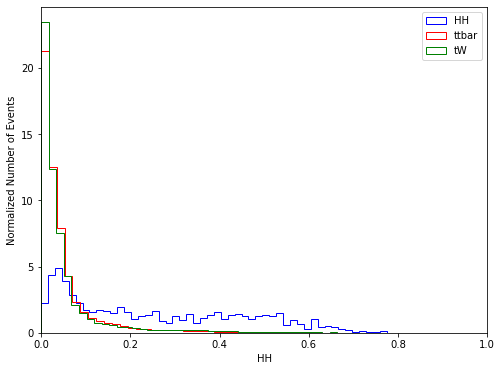

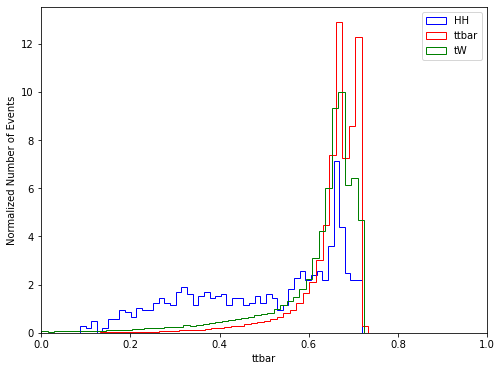

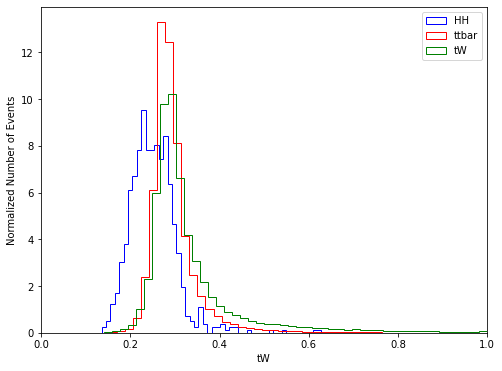

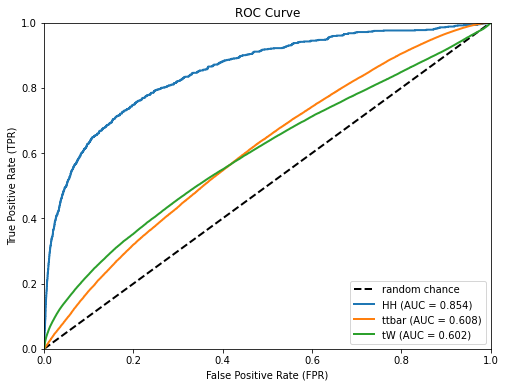

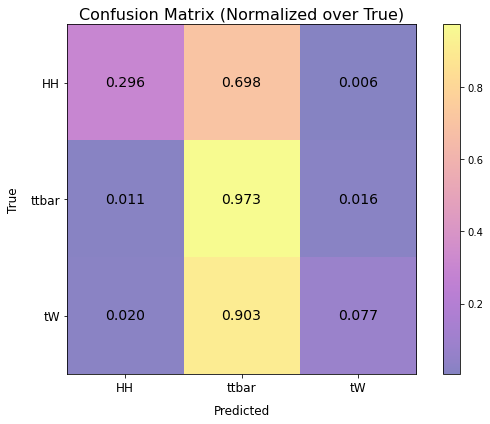

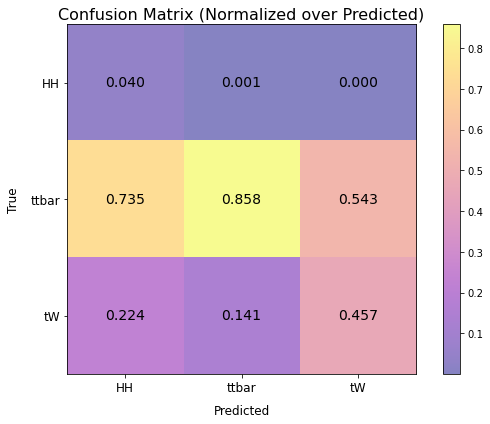

In [5]:
manager = DNNManager(workdir=workdir, sel_name=sel_name, models_yml=models_yml, total_inputs=total_inputs, DNNManagerdir=DNNManagerdir)
manager.set_mode(mode = 'train_eval', rank_features=False)
manager.Run()